# Setup

## Imports

In [1]:
import sys, os
sys.path.insert(0, 'src')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch, math
import random
import re
from collections import Counter
from rank_bm25 import BM25Okapi
import torch

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

from data import (download_msmarco, download_squad, download_nq,
                  chunk_pdfs, load_jsonl, TripletDataset)
from model import TextEncoder
from losses import InfoNCELoss
from retrieval import DenseRetriever, BM25Retriever, TFIDFRetriever
from metrics import run_evaluation, print_metrics
from train import train, load_model
from tokenizer import build_bpe_tokenizer, load_tokenizer

random.seed(42)

In [2]:
data_path = 'data/processed'
data_raw = 'data/raw'
report_path = 'report'

wiki_chunks_path = f'{data_path}/chunks_wiki.jsonl'
nlp_chunks_path = f'{data_path}/chunks_nlp.jsonl'
oov_chunks_path = f'{data_path}/chunks_oov.jsonl'

wiki_eval_path = f'{data_path}/eval_wiki.jsonl'
nlp_eval_path = f'{data_path}/eval_nlp.jsonl'
oov_eval_path = f'{data_path}/eval_oov.jsonl'

## Data Loading

In [3]:
download_msmarco(train_size=100000, val_size=5000, out_dir=data_path)

Data already exists, skipping download.
Train: 100000 triplets | avg query 5.6 words | avg passage 57.4 words
Val: 5000 triplets | avg query 5.7 words | avg passage 57.8 words


In [4]:
download_squad(train_size=80000, val_size=5000, out_dir=data_path)

SQuAD data already exists, skipping.
Train: 80000 triplets | avg query 10.1 words | avg passage 119.4 words
Val: 5000 triplets | avg query 9.7 words | avg passage 124.8 words


In [ ]:
download_nq(train_size=200000, val_size=5000, out_dir=data_path)

# Data Analysis

In [5]:
# ds = 'msmarco'
ds = 'squad'
# ds = 'nq'

train_path = f'{data_path}/{ds}_train_triplets.jsonl'
val_path = f'{data_path}/{ds}_val_triplets.jsonl'

In [6]:
train_triplets = []
with open(train_path) as f:
    for line in f:
        train_triplets.append(json.loads(line))

print(f'Train triplets: {len(train_triplets):,}')
print()
print('Sample triplet:')
t = train_triplets[0]
print(f'Query : {t["query"]}')
print(f'Pos   : {t["pos"]}')
print(f'Neg   : {t["neg"]}')

Train triplets: 80,000

Sample triplet:
Query : To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Pos   : Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.
Neg   : Apollo was worshipped as Actiacus (/ækˈtaɪ.əkəs/ ak-TY-ə-kəs; Ἄκτιακός, Aktiakos, literally "Actian"), Delphinius (/dɛlˈfɪniəs/ del-FIN-ee-əs; Δελφίνιος, Delphinios, li

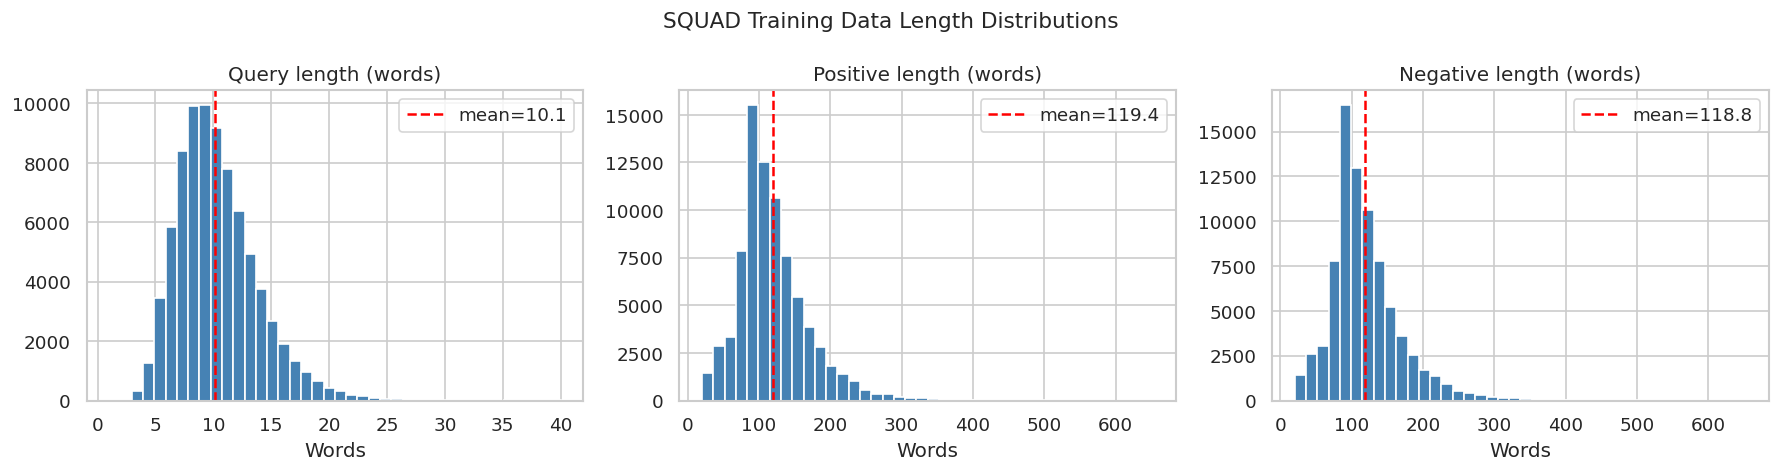

In [7]:
q_lens = [len(t['query'].split()) for t in train_triplets]
p_lens = [len(t['pos'].split()) for t in train_triplets]
n_lens = [len(t['neg'].split()) for t in train_triplets]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
graph_names = ['Query length (words)', 'Positive length (words)', 'Negative length (words)']
for ax, lens, label in zip(axes, [q_lens, p_lens, n_lens], graph_names):
    ax.hist(lens, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('Words')
    ax.axvline(np.mean(lens), color='red', linestyle='--', label=f'mean={np.mean(lens):.1f}')
    ax.legend()
plt.suptitle(f'{ds.upper()} Training Data Length Distributions', fontsize=13)
plt.tight_layout()
plt.savefig(f'{report_path}/{ds}_data_length_distributions.png', bbox_inches='tight')
plt.show()

Positive ranked higher by BM25 : 31.4%
Mean score - pos: -0.10  neg: -0.10


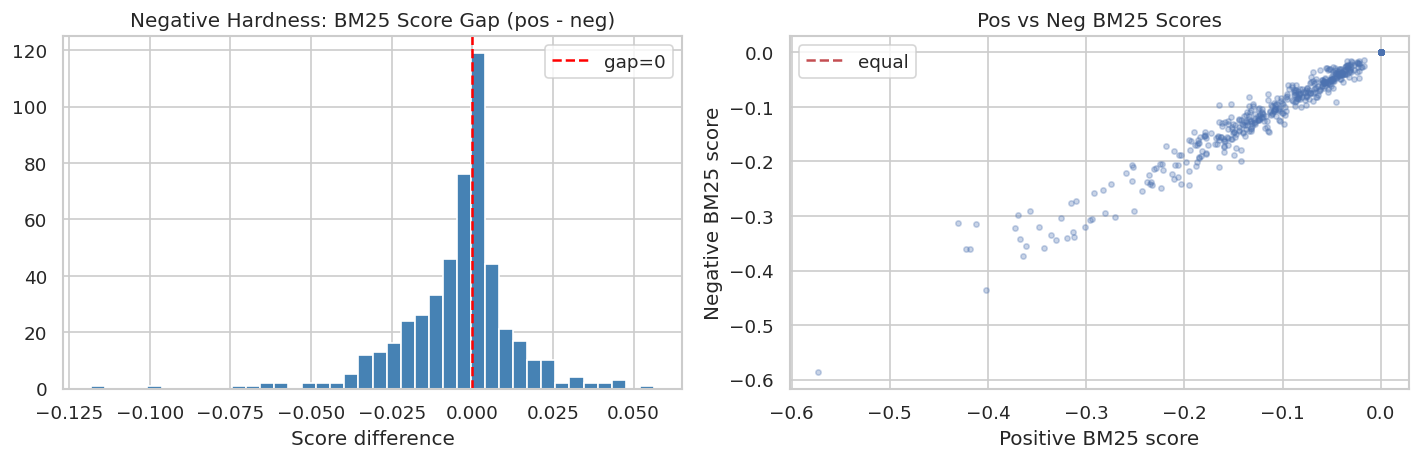

In [8]:
sample = random.sample(train_triplets, min(500, len(train_triplets)))

pos_scores, neg_scores = [], []
for t in sample:
    q_toks = t['query'].lower().split()
    corpus = [t['pos'].lower().split(), t['neg'].lower().split()]
    bm = BM25Okapi(corpus)
    sc = bm.get_scores(q_toks)
    pos_scores.append(sc[0])
    neg_scores.append(sc[1])

gaps = [p - n for p, n in zip(pos_scores, neg_scores)]
pct_pos_higher = sum(1 for g in gaps if g > 0) / len(gaps)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(gaps, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='gap=0')
axes[0].set_title('Negative Hardness: BM25 Score Gap (pos - neg)')
axes[0].set_xlabel('Score difference')
axes[0].legend()

lim = max(max(pos_scores), max(neg_scores)) * 1.05
axes[1].scatter(pos_scores, neg_scores, alpha=0.3, s=10)
axes[1].plot([0, lim], [0, lim], 'r--', label='equal')
axes[1].set_xlabel('Positive BM25 score'); axes[1].set_ylabel('Negative BM25 score')
axes[1].set_title('Pos vs Neg BM25 Scores')
axes[1].legend()

print(f"Positive ranked higher by BM25 : {pct_pos_higher:.1%}")
print(f"Mean score - pos: {sum(pos_scores)/len(pos_scores):.2f}  neg: {sum(neg_scores)/len(neg_scores):.2f}")

plt.tight_layout()
plt.savefig(f'{report_path}/{ds}_triplet_quality.png', bbox_inches='tight')
plt.show()

Loaded data/processed/msmarco_train_triplets.jsonl
Loaded data/processed/squad_train_triplets.jsonl
Loaded J&M chunks (1576 chunks)

Total tokens : 32,477,469
Unique words : 265,104

  min_freq    vocab_size    coverage
         1       265,104    100.00%
         2       164,013     99.69%
         5       112,834     99.28%
        10        79,280     98.57%
        20        50,148     97.36%
        50        28,523     95.30%
       100        18,420     93.12%


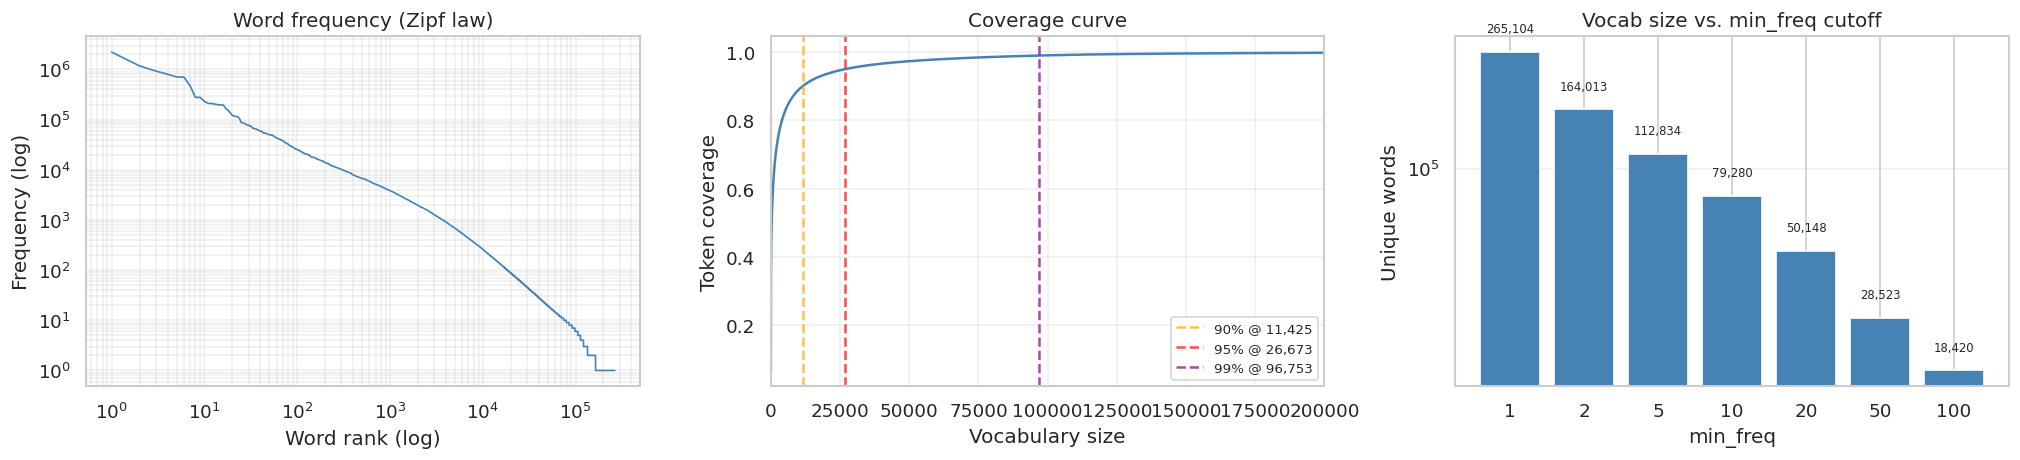

In [9]:
def _tok_split(text):
    return re.sub(r"[^a-z0-9\s'\-]", " ", text.lower()).split()

all_sources = [
    (f'{data_path}/msmarco_train_triplets.jsonl', ['query', 'pos', 'neg']),
    (f'{data_path}/squad_train_triplets.jsonl',   ['query', 'pos', 'neg']),
]

freq = Counter()
total_tokens = 0

for path, fields in all_sources:
    try:
        with open(path) as f:
            for line in f:
                r = json.loads(line)
                for field in fields:
                    if r.get(field):
                        words = _tok_split(r[field])
                        freq.update(words)
                        total_tokens += len(words)
        print(f"Loaded {path}")
    except FileNotFoundError:
        print(f"Skipped {path}")

jm = load_jsonl(nlp_chunks_path)
for c in jm:
    words = _tok_split(c['text'])
    freq.update(words)
    total_tokens += len(words)
print(f"Loaded J&M chunks ({len(jm)} chunks)")

print(f"\nTotal tokens : {total_tokens:,}")
print(f"Unique words : {len(freq):,}")

print(f"\n  {'min_freq':>8}  {'vocab_size':>12}  {'coverage':>10}")
for mf in [1, 2, 5, 10, 20, 50, 100]:
    v = {w for w, c in freq.items() if c >= mf}
    cov = sum(c for w, c in freq.items() if w in v) / total_tokens
    print(f"  {mf:>8}  {len(v):>12,}  {cov:>9.2%}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

sorted_freqs = sorted(freq.values(), reverse=True)
axes[0].loglog(range(1, len(sorted_freqs) + 1), sorted_freqs, lw=1, color='steelblue')
axes[0].set_xlabel('Word rank (log)'); axes[0].set_ylabel('Frequency (log)')
axes[0].set_title('Word frequency (Zipf law)')
axes[0].grid(True, which='both', alpha=0.3)

cum, cx, cy = 0, [], []
for rank, f in enumerate(sorted_freqs, 1):
    cum += f
    cx.append(rank); cy.append(cum / total_tokens)
axes[1].plot(cx, cy, lw=1.5, color='steelblue')
for target, color in [(0.90, 'orange'), (0.95, 'red'), (0.99, 'purple')]:
    for rank, cov in zip(cx, cy):
        if cov >= target:
            axes[1].axvline(rank, linestyle='--', color=color, alpha=0.7,
                            label=f'{target:.0%} @ {rank:,}')
            break
axes[1].set_xlabel('Vocabulary size'); axes[1].set_ylabel('Token coverage')
axes[1].set_title('Coverage curve'); axes[1].legend(fontsize=8)
axes[1].set_xlim(0, min(200_000, len(sorted_freqs))); axes[1].grid(True, alpha=0.3)

cutoffs = [1, 2, 5, 10, 20, 50, 100]
vsizes  = [sum(1 for c in freq.values() if c >= mf) for mf in cutoffs]
axes[2].bar(range(len(cutoffs)), vsizes, tick_label=cutoffs, color='steelblue', edgecolor='white')
axes[2].set_xlabel('min_freq'); axes[2].set_ylabel('Unique words')
axes[2].set_title('Vocab size vs. min_freq cutoff'); axes[2].set_yscale('log')
for i, v in enumerate(vsizes):
    axes[2].text(i, v * 1.15, f'{v:,}', ha='center', va='bottom', fontsize=7)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{report_path}/word_frequency_analysis.png', bbox_inches='tight')
plt.show()


In [10]:
# Run after building the BPE tokenizer in the Training section
bpe_tok = load_tokenizer(f'{data_path}/bpe_tokenizer.json')
chunks = load_jsonl(nlp_chunks_path)

sample_chunks = chunks[:100]
words_total = sum(len(c['text'].split()) for c in sample_chunks)
subwords_total = sum(len(bpe_tok.encode(c['text'])) for c in sample_chunks)

print(f"BPE vocab size    : {len(bpe_tok):,}")
print(f"Sample words      : {words_total:,}")
print(f"Subword tokens    : {subwords_total:,}")

history_path = 'checkpoints/TextEncoder_epoch_10.pt'
print(f"Avg tokens/word   : {subwords_total/words_total:.2f}  (1.0 = no splitting)")

BPE vocab size    : 50,000
Sample words      : 25,000
Subword tokens    : 31,808
Avg tokens/word   : 1.27  (1.0 = no splitting)


In [11]:
samples = random.sample(train_triplets, 5)

for i, t in enumerate(samples, 1):
    print(f"Query    : {t['query']}")
    print(f"Positive : {t['pos']}")
    print(f"Negative : {t['neg']}")
    print()

Query    : The internal stability was known as what?
Positive : Despite the internal stability (known as the paz porfiriana), modernization, and economic growth in Mexico during the Porfiriato from 1876 to 1910, many across the state became deeply dissatisfied with the political system. When Díaz first ran for office, he committed to a strict “No Re-election” policy in which he disqualified himself to serve consecutive terms. Eventually backtracking on many of his initial political positions Díaz became a de facto dictator. Díaz became increasingly unpopular due to brutal suppression of political dissidents by using the Rurales and manipulating the elections to solidify his political machine. The working class was frustrated with the Díaz regime due to the corruption of the political system that had increased the inequality between the rich and poor. The peasants felt disenfranchised by the policies that promoted the unfair distribution of land where 95% of the land was owned by the to

## Chunking

In [ ]:
# Wiki entry
wiki_chunks = chunk_pdfs(f'{data_raw}/ww2.pdf', out_path=wiki_chunks_path)
print()
# NLP book
nlp_chunks = chunk_pdfs(f'{data_raw}/jm.pdf', out_path=nlp_chunks_path)
print()
# OOV entry
oov_chunks = chunk_pdfs(f'{data_raw}/computation.pdf', out_path=oov_chunks_path)

In [12]:
chunks = load_jsonl(nlp_chunks_path)
print(f'Total J&M chunks: {len(chunks)}')

chunk_lens = [c['word_count'] for c in chunks]
print(f'Word count: min={min(chunk_lens)}, max={max(chunk_lens)}, mean={np.mean(chunk_lens):.1f}')

print('Sample chunks:')
for c in chunks[1000:1002]:
    print(f"{c['id']} : {c['text']}")

Total J&M chunks: 1576
Word count: min=52, max=250, mean=249.9
Sample chunks:
chunk_1000 : probabilities of the HMM tagger directly on the hand-tagged data. Then implement the Viterbi algorithm so you can decode a test sentence. Now run your algorithm on the test set. Report its error rate and compare its performance to the most frequent tag baseline. 17.6 Do an error analysis of your tagger. Build a confusion matrix and investigate the most frequent errors. Propose some features for improving the performance of your tagger on these errors. 17.7 Develop a set of regular expressions to recognize the character shape features described on page 398. 17.8 The BIO and other labeling schemes given in this chapter aren’t the only possible one. For example, the B tag can be reserved only for those situations where an ambiguity exists between adjacent entities. Propose a new set of BIO tags for use with your NER system. Experiment with it and compare its performance with the schemes presented in

# Baseline Evaluation

In [13]:
base_chunks_path = wiki_chunks_path
base_eval_path = wiki_eval_path

# base_chunks_path = nlp_chunks_path
# base_eval_path = nlp_eval_path

# base_chunks_path = oov_chunks_path
# base_eval_path = oov_eval_path

In [14]:
chunks = load_jsonl(base_chunks_path)

bm25_ret = BM25Retriever()
bm25_ret.build(chunks)
bm25_ret.save()

tfidf_ret = TFIDFRetriever()
tfidf_ret.build(chunks)
tfidf_ret.save()

BM25 index built over 134 chunks.
BM25 index saved to indexes/bm25.pkl
TF-IDF index built: (134, 5888)
TF-IDF index saved to indexes/tfidf.pkl


In [15]:
# Sanity check
# test_q = 'What is the Viterbi algorithm?'
test_q = 'What is the difference between precision and recall?'
print('BM25 top-5:')
for score, text, chunk_idx in bm25_ret.search(test_q, k=5):
    print(f'{chunk_idx} [{score:.2f}] : {text}')

print('\nTF-IDF top-5:')
for score, text, chunk_idx in tfidf_ret.search(test_q, k=5):
    print(f'{chunk_idx} [{score:.4f}] : {text}')

BM25 top-5:
chunk_0100 [9.60] : C. K. (July 1939). "The Struggle for Mineral Resources". The Annals of the American Academy of Political and Social Science. 204, Democracy and the Americas: 42–48. doi:10.1177/000271623920400107 (https://doi.org/10.1177%2F0002716239204 00107). JSTOR 1021443 (https://www.jstor. org/stable/1021443). "... mineral raw materials ... are the basis of industrial power, and this in turn is the basis of military power. ... England and the United States of America alone control economic proportions of nearly three-fourths of the world's production of minerals. Not less important, they control the seas over which the products must pass." 431. Harrison 1998, p. 3. 432. Compare: Wilson, Mark R. (2016). Destructive Creation: American Business and the Winning of World War II (https://boo ks.google.com/books?id=AcqADAAAQBAJ). American Business, Politics, and Society (reprint ed.). Philadelphia: University of Pennsylvania Press. p. 2. ISBN 978-0-81229354-8. Archived (ht

In [16]:
eval = load_jsonl(base_eval_path)
print(f'Eval queries: {len(eval)}')

bm25_metrics  = run_evaluation(bm25_ret,  eval)
tfidf_metrics = run_evaluation(tfidf_ret, eval)

print_metrics(bm25_metrics,  name='BM25')
print_metrics(tfidf_metrics, name='TF-IDF')

Eval queries: 13
BM25
MRR@1        0.0769
MRR@10       0.1610
MRR@5        0.1308
MeanRank     17.3077
NDCG@1       0.0769
NDCG@10      0.2294
NDCG@5       0.1552
Recall@1     0.0769
Recall@10    0.4615
Recall@5     0.2308
TF-IDF
MRR@1        0.2308
MRR@10       0.3996
MRR@5        0.3654
MeanRank     8.3077
NDCG@1       0.2308
NDCG@10      0.5052
NDCG@5       0.4272
Recall@1     0.2308
Recall@10    0.8462
Recall@5     0.6154


# Training

## Vocab creation

In [17]:
corpus_paths = [
    f'{data_path}/msmarco_train_triplets.jsonl',
    f'{data_path}/squad_train_triplets.jsonl',
    # f'{data_path}/nq_train_triplets.jsonl',
]
chunk_texts = [c['text'] for c in load_jsonl(nlp_chunks_path)]

tokenizer = build_bpe_tokenizer(
    corpus_paths=corpus_paths,
    extra_texts=chunk_texts,
    save_dir=data_path,
    vocab_size=50000,
)
print(f'Vocab size: {len(tokenizer):,}')

Training BPE tokenizer on 2 corpus file(s)



BPE tokenizer saved: data/processed/bpe_tokenizer.json  (vocab_size=50,000)
Vocab size: 50,000


In [18]:
_tok = load_tokenizer("data/processed/vocab.json")

def _split(text):
    return re.sub(r"[^a-z0-9\s'\-]", " ", text.lower()).split()

# Count every token in J&M chunks, separate OOV from in-vocab
oov_counter = Counter()
total, oov_total = 0, 0

for c in load_jsonl(nlp_chunks_path):
    for tok in _split(c["text"]):
        total += 1
        if tok not in _tok.word2id:
            oov_counter[tok] += 1
            oov_total += 1

print(f"Vocab size : {_tok.vocab_size:,}")
print(f"Total tokens in J&M : {total:,}")
print(f"OOV tokens : {oov_total:,}  ({oov_total/total:.1%})")
print()
print("Top-50 most frequent OOV words in J&M chunks:")
print(f"{'word':<20} {'count':>6}")
for word, count in oov_counter.most_common(50):
    print(f"{word:<20} {count:>6}")

Custom tokenizer loaded from data/processed/vocab.json (vocab size: 30,000)
Vocab size : 30,000
Total tokens in J&M : 395,216
OOV tokens : 42,823  (10.8%)

Top-50 most frequent OOV words in J&M chunks:
word                  count
rst                     591
classi                  546
embeddings              450
embedding               343
parsing                 342
coreference             266
softmax                 218
coherence               215
probabilities           213
parse                   184
logistic                183
tagging                 155
nal                     155
wn                      154
x1                      152
speci                   151
feedforward             133
nlp                     132
tokenization            127
cosine                  127
ned                     127
n-gram                  125
w1                      125
syntactic               124
emnlp                   124
bert                    120
yi                      117
encoder-decode

In [19]:
model = TextEncoder()
print(f'TextEncoder parameters: {model.count_parameters():,}')

TextEncoder parameters: 9,788,416


/home/cim/Desktop/Workspace/NLP/final-proj/src/model.py:62: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [20]:
dummy_ids  = torch.randint(1, 1000, (4, 64))
dummy_mask = torch.ones(4, 64, dtype=torch.long)
out = model(dummy_ids, dummy_mask)
print(f'Output shape: {out.shape}') # (4, 256)
print(f'L2 norms: {out.norm(dim=-1)}') # all ~1.0

Output shape: torch.Size([4, 256])
L2 norms: tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<LinalgVectorNormBackward0>)


In [21]:
criterion = InfoNCELoss(temperature=1.0)
B, D = 64, 256
q = torch.nn.functional.normalize(torch.randn(B, D), dim=-1)
p = torch.nn.functional.normalize(torch.randn(B, D), dim=-1)
loss = criterion(q, p)
expected = math.log(B)
print(f'InfoNCE loss (random): {loss.item():.4f} (expected ~ {expected:.4f})')

InfoNCE loss (random): 4.1544 (expected ~ 4.1589)


In [22]:
train()

Training on device: cuda
Loading datasets
  train: 180,000  |  val: 5,000
Model parameters: 14,908,416
Epoch 1/20 | Step 100/704 | Loss 5.4787 | LR 2.00e-04
Epoch 1/20 | Step 200/704 | Loss 5.3010 | LR 4.00e-04
Epoch 1/20 | Step 300/704 | Loss 5.1067 | LR 6.00e-04
Epoch 1/20 | Step 400/704 | Loss 5.0253 | LR 8.00e-04
Epoch 1/20 | Step 500/704 | Loss 4.8964 | LR 1.00e-03
Epoch 1/20 | Step 600/704 | Loss 4.7500 | LR 1.00e-03
Epoch 1/20 | Step 700/704 | Loss 4.5921 | LR 9.99e-04
Epoch 1 | Val loss: 4.8501
  New best model saved (val_loss=4.8501)
Epoch 2/20 | Step 100/704 | Loss 4.3645 | LR 9.99e-04
Epoch 2/20 | Step 200/704 | Loss 4.2152 | LR 9.98e-04
Epoch 2/20 | Step 300/704 | Loss 4.0595 | LR 9.97e-04
Epoch 2/20 | Step 400/704 | Loss 3.8794 | LR 9.95e-04
Epoch 2/20 | Step 500/704 | Loss 3.6689 | LR 9.93e-04
Epoch 2/20 | Step 600/704 | Loss 3.4898 | LR 9.91e-04
Epoch 2/20 | Step 700/704 | Loss 3.3470 | LR 9.89e-04
Epoch 2 | Val loss: 3.7047
  New best model saved (val_loss=3.7047)
Epoch

{'train_loss': [5.9016265869140625,
  5.908138275146484,
  5.885078430175781,
  5.9057769775390625,
  5.893047332763672,
  5.828277587890625,
  5.8075714111328125,
  5.769702911376953,
  5.783657073974609,
  5.700065612792969,
  5.688941955566406,
  5.668205261230469,
  5.6540985107421875,
  5.608924865722656,
  5.5862579345703125,
  5.591316223144531,
  5.5666351318359375,
  5.5561370849609375,
  5.537689208984375,
  5.534629821777344,
  5.523155212402344,
  5.518226623535156,
  5.5112762451171875,
  5.492134094238281,
  5.469261169433594,
  5.498779296875,
  5.466911315917969,
  5.4639129638671875,
  5.462432861328125,
  5.424652099609375,
  5.435943603515625,
  5.382354736328125,
  5.4070892333984375,
  5.392692565917969,
  5.487762451171875,
  5.403114318847656,
  5.351310729980469,
  5.496360778808594,
  5.4427337646484375,
  5.472572326660156,
  5.36358642578125,
  5.418449401855469,
  5.443084716796875,
  5.417442321777344,
  5.411949157714844,
  5.435211181640625,
  5.452781677

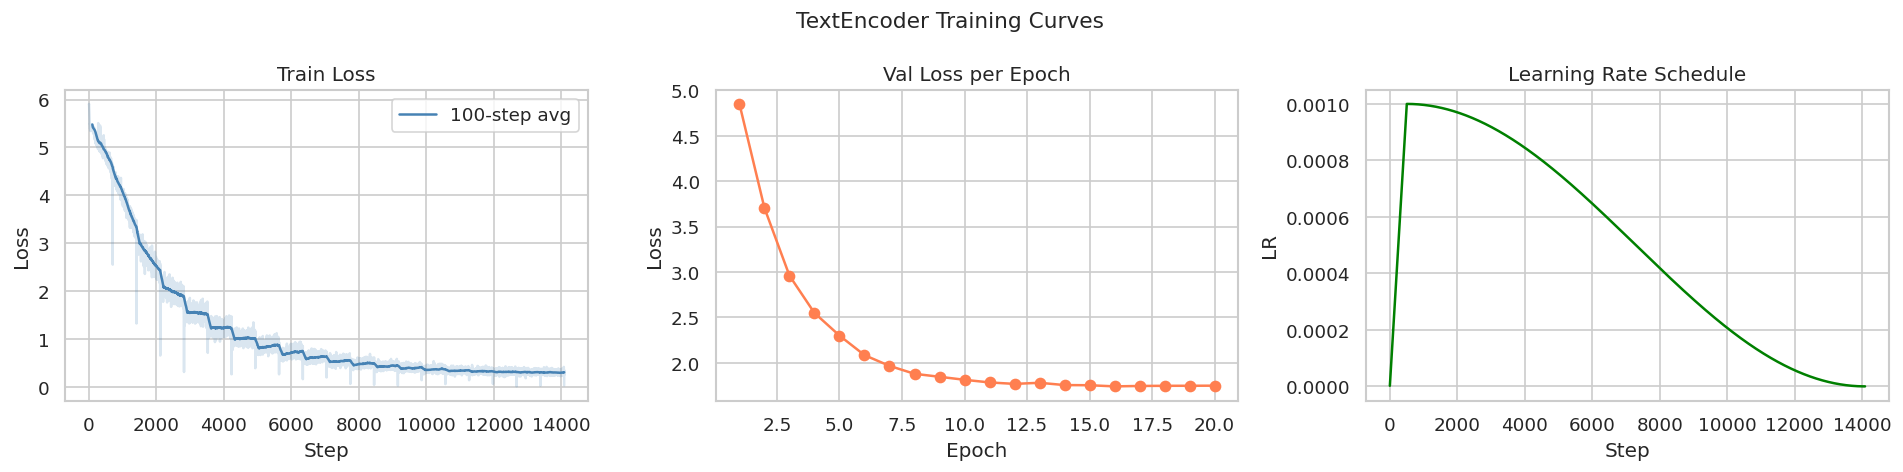

Saved to report/training_curves.png


In [23]:
history_path = 'checkpoints/TextEncoder-4L-256d-scratch/training_history.json'
with open(history_path) as f:
    history = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

steps  = history['train_step']
losses = history['train_loss']
axes[0].plot(steps, losses, alpha=0.2, color='steelblue')
window = min(100, len(losses))
if len(losses) >= window:
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    axes[0].plot(steps[window-1:], smoothed, color='steelblue', label=f'{window}-step avg')
    axes[0].legend()
axes[0].set_title('Train Loss'); axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')

axes[1].plot(history['val_epoch'], history['val_loss'], marker='o', color='coral')
axes[1].set_title('Val Loss per Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')

axes[2].plot(steps, history['train_lr'], color='green')
axes[2].set_title('Learning Rate Schedule'); axes[2].set_xlabel('Step'); axes[2].set_ylabel('LR')

plt.suptitle('TextEncoder Training Curves', fontsize=13)
plt.tight_layout()
os.makedirs(report_path, exist_ok=True)
plt.savefig(f'{report_path}/training_curves.png', bbox_inches='tight')
plt.show()
print(f"Saved to {report_path}/training_curves.png")

# Results & Comparison

In [37]:
res_chunks_path = wiki_chunks_path
res_eval_path = wiki_eval_path

In [38]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, tokenizer = load_model('checkpoints/TextEncoder-4L-256d-scratch/best_model.pt', device=device)

chunks = load_jsonl(res_chunks_path)

dense_ret = DenseRetriever(d_model=256)
dense_ret.build(chunks, model, tokenizer, device=device)
dense_ret.save()

bm25_ret = BM25Retriever()
bm25_ret.build(chunks)
bm25_ret.save()

tfidf_ret = TFIDFRetriever()
tfidf_ret.build(chunks)
tfidf_ret.save()

/home/cim/Desktop/Workspace/NLP/final-proj/src/model.py:62: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Encoding 134 chunks...
Dense index built: 134 vectors of dim 256
Saved dense index to indexes/jm_corpus.npy, chunk map to indexes/jm_chunks_map.json
BM25 index built over 134 chunks.
BM25 index saved to indexes/bm25.pkl
TF-IDF index built: (134, 5888)
TF-IDF index saved to indexes/tfidf.pkl


In [39]:
test_text = chunks[0]['text']
results = dense_ret.search(test_text, model, tokenizer, k=1, device=device)
print(f'Self-retrieval score: {results[0][0]:.6f}  (expected ≈ 1.0)')

Self-retrieval score: 0.857390  (expected ≈ 1.0)


In [40]:
eval_qrels = load_jsonl(res_eval_path)

bm25_ret.load('indexes/bm25.pkl')
tfidf_ret.load('indexes/tfidf.pkl')

bm25_metrics   = run_evaluation(bm25_ret,  eval_qrels)
tfidf_metrics  = run_evaluation(tfidf_ret, eval_qrels)
neural_metrics = run_evaluation(
    dense_ret, eval_qrels,
    model=model, tokenizer=tokenizer, device=device
)

print_metrics(bm25_metrics, 'BM25')
print_metrics(tfidf_metrics, 'TF-IDF')
print_metrics(neural_metrics, 'Neural (TextEncoder + Dense)')

BM25 index loaded: 134 chunks
TF-IDF index loaded: 134 chunks
BM25
MRR@1        0.0769
MRR@10       0.1610
MRR@5        0.1308
MeanRank     17.3077
NDCG@1       0.0769
NDCG@10      0.2294
NDCG@5       0.1552
Recall@1     0.0769
Recall@10    0.4615
Recall@5     0.2308
TF-IDF
MRR@1        0.2308
MRR@10       0.3996
MRR@5        0.3654
MeanRank     8.3077
NDCG@1       0.2308
NDCG@10      0.5052
NDCG@5       0.4272
Recall@1     0.2308
Recall@10    0.8462
Recall@5     0.6154
Neural (TextEncoder + Dense)
MRR@1        0.0769
MRR@10       0.1707
MRR@5        0.1526
MeanRank     17.6923
NDCG@1       0.0769
NDCG@10      0.2555
NDCG@5       0.2080
Recall@1     0.0769
Recall@10    0.5385
Recall@5     0.3846


        MRR@1  MRR@10  MRR@5  MeanRank  NDCG@1  NDCG@10  NDCG@5  Recall@1  Recall@10  Recall@5
BM25   0.0769  0.1610 0.1308   17.3077  0.0769   0.2294  0.1552    0.0769     0.4615    0.2308
TF-IDF 0.2308  0.3996 0.3654    8.3077  0.2308   0.5052  0.4272    0.2308     0.8462    0.6154
Neural 0.0769  0.1707 0.1526   17.6923  0.0769   0.2555  0.2080    0.0769     0.5385    0.3846


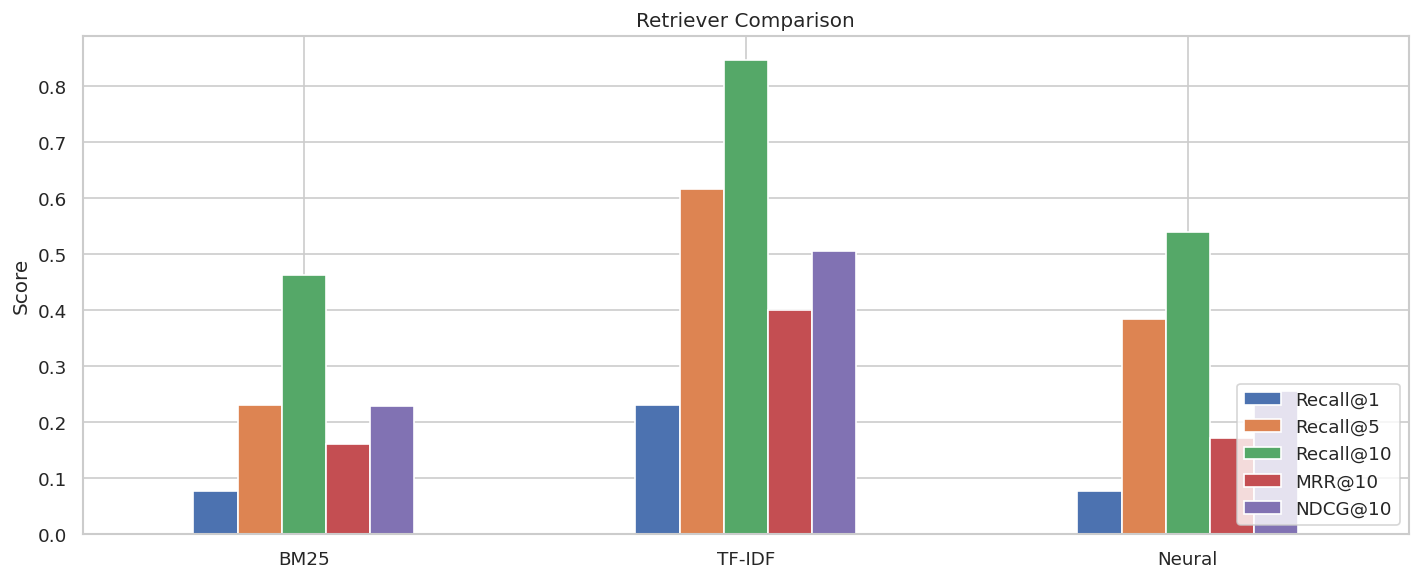

In [42]:
all_metrics = {
    'BM25':   bm25_metrics,
    'TF-IDF': tfidf_metrics,
    'Neural': neural_metrics,
}
df = pd.DataFrame(all_metrics).T
df = df[sorted(df.columns)]
print(df.to_string(float_format='{:.4f}'.format))

metrics_to_plot = ['Recall@1', 'Recall@5', 'Recall@10', 'MRR@10', 'NDCG@10']
plot_df = df[metrics_to_plot]
ax = plot_df.plot(kind='bar', figsize=(12, 5), rot=0)
ax.set_title('Retriever Comparison')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('report/metric_comparison.png', bbox_inches='tight')
plt.show()

In [44]:
queries = [q['query'] for q in eval_qrels[:5]]
for query in queries:
    print(f'\nQuery: {query}')
    print('BM25 top-1 :', bm25_ret.search(query, k=1)[0][1])
    print('TF-IDF top-1 :', tfidf_ret.search(query, k=1)[0][1])
    print('Neural top-1 :', dense_ret.search(query, model, tokenizer, k=1, device=device)[0][1])


Query: How many people died in World War II and what caused the most deaths?
BM25 top-1 : material losses, also experienced rapid increases in production in the immediate postwar era,[369] having seized and transferred most of Germany's industrial plants and exacted war reparations from its satellite states.[d][370] Japan recovered much later.[371] China returned to its pre-war industrial production by 1952.[372] An estimated 60 million to more than 75 million people died in the war including at least 20 million who died from deprivation, famine and disease.[373][374][375][376] Civilian deaths have been estimated to comprise 67%[377] to 80%[378] of all direct and indirect deaths from the war. The Soviet Union had the highest overall death toll (estimated at 20 million to 28 million),[379] followed by China (at least 15 million),[374][380][381] Germany (6 million to 8.7 million)[382][381] and Poland (5 million to 6.5 million).[374][381] The countries which sustained the most military d